In [1]:
# ======= FAST JAX UTILS FOR COMPOSITE PULSES =======
import time
from functools import partial
from Helper_functions_cp import *
import jax
import jax.numpy as jnp
from typing import Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator



# --- put this near your other imports ---
from functools import lru_cache, partial

# ---------------- Constants & dtypes ----------------
DT_C = jnp.complex64
DT_R = jnp.float32
PI   = jnp.pi

# Targets hoisted (no re-creation inside jit)
X_GATE = -1j* jnp.array([[0., 1.],
                    [1., 0.]], dtype=DT_C)

# Rx(pi/2) (your default target in gate_fidelity)RX_3PI_OVER_2
#X_GATE = (1/jnp.sqrt(jnp.array(2., DT_R))) * jnp.array(
#    [[1., -1j],
#     [-1j, 1.]], dtype=DT_C
#)

EYE2 = jnp.eye(2, dtype=DT_C)


@jax.jit
def single_U(a: DT_R, eps: DT_R, delt: DT_R, phi: DT_R, time_eps: bool = False) -> jnp.ndarray:
    RT, CT = DT_R, DT_C

    # amplitude and duration
    if time_eps:
        Omega = jnp.array(a, RT)               # no amplitude error
        T     = jnp.array(1.0 + eps, RT)      # time error
    else:
        T     = jnp.array(1.0, RT)
        Omega = jnp.array(a, RT) * (1.0 + jnp.array(eps, RT))

    delt  = jnp.array(delt, RT) #* a
    phi   = jnp.array(phi,  RT)

    Q     = jnp.sqrt(delt * delt + Omega * Omega)  # ≥ 0
    theta = 0.5 * jnp.pi * Q * T                   # correct angle
    cosθ  = jnp.cos(theta)

    # Need sin(theta)/Q with the SAME theta (includes T!)
    def _safe_sin_over_q(q):
        th = 0.5 * jnp.pi * q * T
        return jnp.where(q > jnp.array(1e-12, RT),
                         jnp.sin(th) / q,
                         0.5 * jnp.pi * T)   # lim_{q->0} sin(th)/q → th/q = (π T)/2

    s_over_Q = _safe_sin_over_q(Q)

    # e^{-i π φ}
    ang = -jnp.pi * phi
    exp_miπφ = jnp.cos(ang) - 1j * jnp.sin(ang)
    exp_piπφ = jnp.conj(exp_miπφ)

    iδs = 1j * delt  * s_over_Q
    iΩs = 1j * Omega * s_over_Q

    U = jnp.array([
        [cosθ - iδs,          -iΩs * exp_miπφ],
        [-iΩs * exp_piπφ,      cosθ + iδs     ],
    ], dtype=CT)
    
    return U


def generate_nb_phases(N):
    if N % 2 == 0:
        raise ValueError("N must be an odd integer.")
        
    k = np.arange(1, N + 1)
    
    phases = np.where(k % 2 == 0, 
                      (k) / N, 
                      -(k - 1)/ N)
                      
    return np.concatenate([phases,np.ones(len(phases))])

# ---------------- Composite executors ----------------
@jax.jit
def composite_U(a_vec: jnp.ndarray,
                eps: DT_R,
                delt: DT_R,
                phi_vec_internal: jnp.ndarray) -> jnp.ndarray:
    
    def body(U_tot, a_phi):
        a_i, phi_i = a_phi
        U_i = single_U(a_i, eps, delt, phi_i)
        return (U_i @ U_tot, None)
    
    aphis = jnp.stack([a_vec, phi_vec_internal], axis=0)  # (2,K)
    U_final, _ = jax.lax.scan(body, EYE2, aphis.swapaxes(0,1))  # scan over K
    return U_final

# ---------------- Your “expand” + generic fidelity ----------------
@jax.jit
def expand_phis(core_phis: jnp.ndarray) -> jnp.ndarray:
    return jnp.asarray(core_phis, dtype=DT_R)

@partial(jax.jit, static_argnames=('use_amplitude'))
def gate_fidelity(eps, delt, phi_vec_core, *,
                  use_amplitude: bool = True, infidelity:bool = True, target = X_GATE):


    phis = expand_phis(phi_vec_core[:phi_vec_core.shape[0]//2] if use_amplitude
                       else phi_vec_core)

    if use_amplitude:
        alphas = expand_phis(phi_vec_core[phi_vec_core.shape[0]//2:])
        U = composite_U(alphas, eps, delt, phis)
    else:
        U = composite_U(jnp.ones_like(phis), eps, delt, phis)
    
    Ud = U.conj().T
    tr = jnp.trace(Ud @ X_GATE)
    d  = jnp.array(2.0, DT_R)
    return 1.0 - (jnp.abs(tr)**2 + d) / (d * (d + 1.0))
    #pik = U @ U
    #return (jnp.abs(U[0,0])**2)
    #return jnp.abs(1/2 - jnp.abs(U[1,0])**2)
    #diff = U.conj().T @ target
    #p0 = diff[0,0]
    #return 1 - jnp.absolute(p0) ** 2


from functools import partial
import jax
import jax.numpy as jnp

# ---------------- Derivatives (configurable order) ----------------


def _f_z(z, phis, *, infidelity, use_amplitude, target):
    return gate_fidelity(z[0], z[1], phis,
                         infidelity=infidelity,
                         use_amplitude=use_amplitude,
                         target=(X_GATE if target is None else target))


# ===================== Benchmark helpers =====================
import time
from functools import partial, lru_cache

def time_compile(jitted_fn, *args, label="compile"):
    """Trace+compile only; returns compiled callable."""
    lowered  = jitted_fn.lower(*args)
    t0 = time.perf_counter()
    compiled = lowered.compile()
    t1 = time.perf_counter()
    print(f"{label:30s}: {(t1 - t0)*1e3:8.2f} ms [compile]")
    return compiled

def time_exec(compiled_fn, *args, iters=100, label="exec"):
    """Steady-state runtime; includes .block_until_ready()."""
    compiled_fn(*args).block_until_ready()  # warm
    t0 = time.perf_counter()
    for _ in range(iters):
        compiled_fn(*args).block_until_ready()
    t1 = time.perf_counter()
    print(f"{label:30s}: {(t1 - t0)*1e3/iters:8.3f} ms/call [exec]")


def build_cost_fn(infidelity: bool = False, use_amplitude: bool = True,order =1):
    epsilon_grid = jnp.linspace(-0.2, 0.2, 8)
    delta_grid   = jnp.linspace(-0.2, 0.2, 8)
    if order == 1:
            epsilon_grid = jnp.linspace(-0.1, 0.1, 8)
            delta_grid   = jnp.linspace(-0.1, 0.1, 8)
    eps_delt_grid = jnp.array(jnp.meshgrid(epsilon_grid, delta_grid)).T.reshape(-1,2)

    @partial(jax.jit, static_argnames=('infidelity','use_amplitude'))
    def cost_at_point(z, phis, target=None, *, infidelity=infidelity, use_amplitude=use_amplitude):
        total = 0.0
        for eps, delt in eps_delt_grid:
            f = gate_fidelity(eps, delt, phis, infidelity=infidelity, use_amplitude=use_amplitude, target=target)
            total += jnp.abs(f)
        return total/len(eps_delt_grid)**2
    return cost_at_point

@lru_cache(maxsize=None)
def build_derivative_cost_fn(order: int = 4, infidelity: bool = False, use_amplitude: bool = True):
    # Derivatives w.r.t. z=(eps, delt); 'phis' is a normal dynamic arg
    val_and_grad = jax.value_and_grad(_f_z, argnums=0)
    hess_fun   = jax.jacfwd(jax.grad(_f_z, argnums=0), argnums=0) if order >= 2 else None
    third_fun  = jax.jacfwd(hess_fun,  argnums=0) if order >= 3 else None
    fourth_fun = jax.jacfwd(third_fun, argnums=0) if order >= 4 else None

    @partial(jax.jit, static_argnames=('infidelity','use_amplitude','order'))
    def cost_at_point(z, phis, target=None, *, infidelity=infidelity, use_amplitude=use_amplitude, order=order):
        f, g = val_and_grad(z, phis, infidelity=infidelity, use_amplitude=use_amplitude, target=target)
        total = jnp.abs(f) + 0.5*jnp.sum(jnp.abs(g))
        if order >= 2:
            H  = hess_fun(z, phis, infidelity=infidelity, use_amplitude=use_amplitude, target=target)
            total += 0.25*jnp.sum(jnp.abs(H))
        if order >= 3:
            T3 = third_fun(z, phis, infidelity=infidelity, use_amplitude=use_amplitude, target=target)
            total += 0.125*jnp.sum(jnp.abs(T3))
        if order >= 4:
            T4 = fourth_fun(z, phis, infidelity=infidelity, use_amplitude=use_amplitude, target=target)
            total += (1/16.)*jnp.sum(jnp.abs(T4))
        return total

    return cost_at_point

# Convenience wrapper with same call style as before (optional)
def Cost_function_fast(phis, *, eps=0.0, delt=0.0, order=2, infidelity=True, use_amplitude=True, target=None):
    cost = build_cost_fn(infidelity=infidelity, use_amplitude=use_amplitude)
    z = jnp.array([eps, delt], dtype=DT_R)
    return cost(z, jnp.asarray(phis, dtype=DT_R), target=target)

# ===================== Integrated demo =====================
def demo_bench():
    # Example data (adjust K as needed)
    K = 7
    phis   = jnp.linspace(0., 2*PI, K, dtype=DT_R)
    alphas = jnp.ones_like(phis) * jnp.array(0.5, DT_R)  # area = 0.5*pi segments
    core   = jnp.concatenate([phis, alphas])             # use_amplitude=True expects [phis|alphas]

    seq = jnp.stack([alphas * PI, phis * PI], axis=1)    # (K,2) angles, phases in radians

    eps  = jnp.array(0.01, DT_R)
    delt = jnp.array(0.02, DT_R)
    z0   = jnp.array([0.0, 0.0], DT_R)

    # --- Build jitted callables for clean compile/exec timing ---
    jit_gf_L2   = jax.jit(lambda e, d, c: gate_fidelity(e, d, c, infidelity=True, use_amplitude=True))

    cost_order2 = build_derivative_cost_fn(order=2, infidelity=False, use_amplitude=True)  # already jitted
    cost_order3 = build_cost_fn(infidelity=False, use_amplitude=True)

    # ------------- True compile times -------------
    c3 = time_compile(jit_gf_L2,   eps, delt, core,           label="compile gate_fidelity (L2)")
    c4 = time_compile(cost_order2, z0,  core,                 label="compile Cost_function(order=2)")
    c5 = time_compile(cost_order3, z0,  core,                 label="compile Cost_function(order=3)")

    # ------------- Steady-state execution times -------------
    time_exec(c3, eps, delt, core,           iters=1200, label="gate_fidelity (L2 to target)")
    time_exec(c4, z0,  core,                 iters=1200, label="Cost_function (order=2)")
    time_exec(c5, z0,  core,                 iters=1200, label="Cost_function (order=3)")


#demo_bench()

In [2]:
def plot_contours(results1,order = 3,range = 0.2,N_POINTS = 1000, name = '',operator = 'Narrowband',aditional_name = ''):
    
    error_alpha = jnp.linspace(-range, range, N_POINTS)   # eps axis (columns)
    error_delta = jnp.linspace(-range, range, N_POINTS)   # delta axis (rows)

    # Enable LaTeX rendering globally
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
    })

    # --- your data ---
    P, D = np.meshgrid(error_alpha, error_delta)
    Z = np.asarray(results1, dtype=float).T

    # avoid issues with zeros/negatives for log-like contours
    Z_plot = np.where(Z > 0, Z, np.nan)

    # choose powers & levels 10^exponents
    exponents = np.arange(-4, 0)                 # [-7, -6, ..., -1]
    levels = 10.0 ** exponents
    #levels = [0.03, 0.01, 0.003, 0.001, 0.0003, 0.00001][::-1]

    # distinct colors
    cmap = plt.get_cmap("viridis")
    colors = [cmap(t) for t in np.linspace(0.05, 0.95, len(levels))]
    def label_fmt(v):
        k = int(np.round(np.log10(v)))
        return rf"$10^{{{k}}}$"   # LaTeX math mode

    fig, ax = plt.subplots(figsize=(8, 7))

    # contour lines
    font_razmer = 25
    CS = ax.contour(P, D, Z_plot, levels=levels, colors=colors, linewidths=1.8)
    ax.clabel(CS, inline=True, fmt=label_fmt, fontsize=font_razmer)

    # polish
    if operator == 'Time_robust_x':
      ax.set_ylabel(r"Pulse duration error",fontsize = font_razmer + 16)
    else:
      ax.set_ylabel(r"Rabi frequency error $\epsilon$",fontsize = font_razmer + 16)
    ax.set_xlabel(r"Detuning error $\delta$",fontsize = font_razmer + 15)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis="both", which="major", labelsize=font_razmer + 6)   # numbers on x & y

    for s in ax.spines.values():
        s.set_linewidth(0.6)

    plt.tight_layout()
    plt.show()
    #if name != '':
    #   plt.savefig(f"Plots\\{operator}\\{name}.svg", dpi=300)
    #else:
    #    plt.savefig(f"Plots\\{operator}\\N={order}_times_robust_non_rob.svg", dpi=300)
    
 
    plt.close()

def other_plot(results1,range = 0.2,N_POINTS = 1000, name = '',operator = 'Nikolay',aditional_name = ''):
       
    epsilon_values = jnp.linspace(-range, range, N_POINTS)   # eps axis (columns)
    delta_values = jnp.linspace(-range, range, N_POINTS)   # delta axis (rows)

    X, Y = np.meshgrid(epsilon_values, delta_values, indexing="ij")
    
    vminpower = 5
    VMIN = 10.**(-vminpower)
    ticks = 10.**(-np.arange(vminpower+1))
    
    Z_ideal = np.where(results1 < VMIN, VMIN+0.0000000001, results1)
    levels_i = np.logspace(np.log10(VMIN), np.log10(1.), vminpower+1)
    plt.figure()
    cf = plt.contourf(X, Y, Z_ideal, levels=levels_i, norm=LogNorm(vmin=VMIN, vmax=1.0))
    plt.colorbar(cf, ticks=ticks, label='Infidelity (log scale)')
    plt.ylabel('Epsilon (Amplitude Error)')
    plt.xlabel('Delta (Detuning Error)')
    plt.title('Fidelity Landscape (ideal)')
    plt.tight_layout()
    plt.show()
    plt.savefig(f"Plots\\{operator}\\{name}.svg", dpi=300)
    plt.close()

def parametrite_2d(n,ifh = False,iteration = 0):
    if ifh:    
       param_file = np.load(os.path.join("Parameters", f"Universal_half_pop_{n}_{iteration}.npy"))
       param_file[n:] = param_file[n:]/2
    else:
       param_file = np.load(os.path.join("Parameters", f"phi_array_{n}_time_robust_x_{iteration}.npy"))
    
    return param_file


def other_plot1(results1,results2,range = 0.2,N_POINTS = 1000, name = '',operator = 'Nikolay',aditional_name = ''):
       
    epsilon_values = jnp.linspace(-range, range, N_POINTS)   # eps axis (columns)
    
    plt.figure()
    plt.plot(epsilon_values, results1,label = 'Prolonged')
    plt.plot(epsilon_values, results2,label = 'CP17')
    plt.legend()
    #plt.yscale('log')
    plt.ylabel('Epsilon (Amplitude Error)')
    plt.xlabel('Delta (Detuning Error)')
    plt.title('Fidelity Landscape (ideal)')
    plt.tight_layout()
    plt.show()
    plt.savefig(f"Plots\\{operator}\\{name}.svg", dpi=300)
    plt.close()
    #print((results1[N_POINTS//2] - results2[N_POINTS//2])[-1])

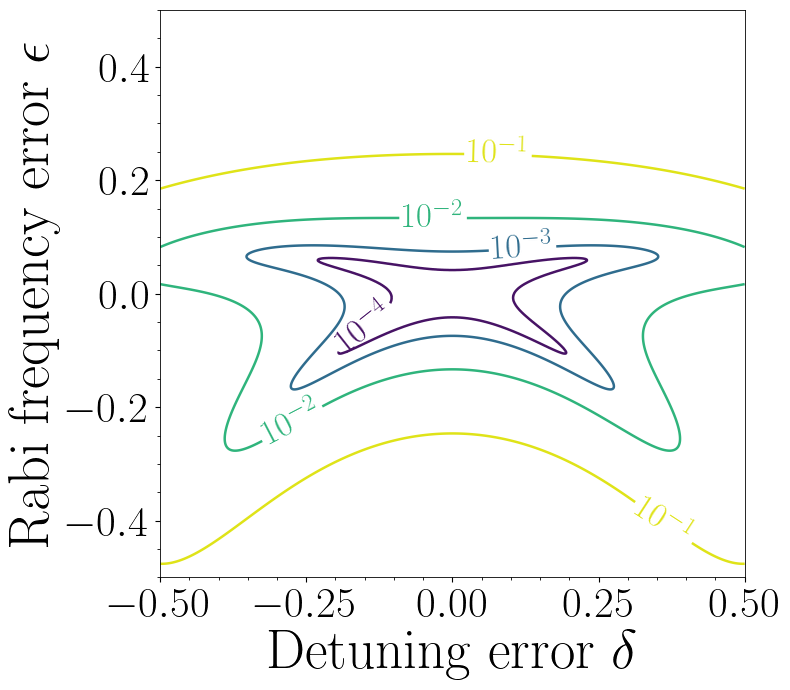

In [4]:
import jax
import jax.numpy as jnp

points,points2 = [],[]
epsilon_list = []
full_pop = True
prolonged = False
N_POINTS = 1001
bounds = .5
epsilon_values = jnp.linspace(-bounds, bounds, N_POINTS)
for n in [5]:
    if full_pop:
       loaded1 = np.load(f"Parameters\\Vitanov_U_{n}_a_x.npy")
    else:
     if n == 0:
      loaded1  = np.array([0,1])
     else:
      loaded1  = parametrite_2d(9,ifh = True,iteration= n)

    # Grids
    error_alpha = jnp.linspace(-bounds, bounds, N_POINTS)   # eps axis (columns)
    error_delta = jnp.linspace(-bounds, bounds, N_POINTS)   # delta axis (rows)
    
    corpse    = corpse_pulse(np.pi, base_phase=0.0)
    b3r       = scrofulous(math.pi, base_phase=0.0)
    b3d       = np.array([2/3,1/3,2/3,1.,1.,1.])
    knill     = knill_5pulse(theta=np.pi, base_phase=0.0)
    ths, phs  = bn_thetas_phis(np.pi, n=2, include_base=False)
    bbedno    = jnp.array([(thi, phi) for thi, phi in zip(np.concatenate([[np.pi],ths]), np.concatenate([[0],phs]))])
    def _sweep_for_theta(theta: jnp.ndarray) -> jnp.ndarray:
        def row(delta):
            return jax.vmap(lambda eps: gate_fidelity(eps, delta, theta))(error_alpha)
        return jax.vmap(row)(error_delta)


    sweep_fidelity = jax.jit(_sweep_for_theta)
    results5_rounded = sweep_fidelity(loaded1)       # shape (N_POINTS, N_POINTS)

    results5_rounded_np = np.array(jnp.array(results5_rounded).copy())
  
    plot_contours(results5_rounded_np,order =  n,range = bounds,N_POINTS = N_POINTS, name = f'N={n}_times_robust_non_rob')
